In [1]:
# [C01] Setup & imports
# Description: Import libraries and define small helpers we’ll use everywhere.

from pathlib import Path
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

from IPython.display import display

# optional nicer pitch
try:
    from mplsoccer import Pitch
    HAS_MPLSOCCER = True
except Exception:
    HAS_MPLSOCCER = False

def pick_col(df, *cands):
    """Return the first existing column name from candidates; else None."""
    for c in cands:
        if c in df.columns:
            return c
    return None


In [2]:
# [C02] Find or clone the dataset
# Description: Try common locations for the repo; if missing, clone it into the notebook folder.

REPO_NAME = "twelve-respovision-CL-final"
CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path.home(),
    Path.home() / "Documents",
    Path.home() / "Desktop",
]

repo_dir = None
for root in CANDIDATES:
    p = root / REPO_NAME / "Data"
    if p.exists():
        repo_dir = root / REPO_NAME
        break

if repo_dir is None:
    # Attempt to clone (requires git installed). If git isn't available, you'll see an error here.
    try:
        # Jupyter shell command
        !git clone https://github.com/twelvefootball/twelve-respovision-CL-final
        repo_dir = Path.cwd() / REPO_NAME
    except Exception as e:
        repo_dir = None
        print("Git clone failed:", e)

if repo_dir is None or not (repo_dir / "Data").exists():
    raise FileNotFoundError(
        "Could not find or clone the dataset. "
        "If git is not installed, manually download the repo and set repo_dir = Path('path/to/repo')."
    )

DATA_DIR = repo_dir / "Data"
print("Using DATA_DIR:", DATA_DIR)
print("Contains:", [x.name for x in DATA_DIR.iterdir()])


Using DATA_DIR: C:\Users\Rafallex\twelve-respovision-CL-final\Data
Contains: ['18768058_events.parquet', '18768058_runs.parquet', '18768058_stories.parquet', '18768058_tracks.parquet']


In [3]:
# [C03] Load runs file safely
# Description: Load the parquet file and show basic info. Adjust the filename here if needed.

RUNS_FILE = None
# Prefer a file that ends with "_runs.parquet"
for f in DATA_DIR.glob("*_runs.parquet"):
    RUNS_FILE = f
    break

if RUNS_FILE is None:
    raise FileNotFoundError("No *_runs.parquet found in Data/. Please check the repo contents.")

runs = pd.read_parquet(RUNS_FILE)
print("Loaded:", RUNS_FILE.name, "shape:", runs.shape)
runs.head(3)


Loaded: 18768058_runs.parquet shape: (805, 28)


,player_id,jersey,team,frame_start,frame_end,start_x,start_y,end_x,end_y,max_speed,...,team_id,approx_time_start,approx_time_end,Forward runs,Distance,Runs into box,xGRun,In possession runs,possession_id,Target
0,home_team_player_10,10,home_team,1279,1357,54.198198,81.201682,35.902647,91.648976,25.990283,...,1625,51160.0,54280.0,False,20.481841,False,0.0000,False,1670469650,False
1,home_team_player_10,10,home_team,7216,7250,78.752550,74.942682,84.251781,66.981610,21.529320,...,1625,288640.0,290000.0,True,7.915024,True,0.0615,True,1670470679,False
2,home_team_player_10,10,home_team,14178,14250,59.866674,82.591450,71.969354,61.423390,26.396568,...,1625,567120.0,570000.0,False,19.201143,False,0.0000,False,1670469841,False


In [13]:
# [C04] Standardize essential columns
# Description: Map whatever the dataset uses (start_x/x_start, player/player_name, etc.) into a common schema.

col_player = pick_col(runs, "player", "player_name", "name")
col_sx     = pick_col(runs, "start_x", "x_start", "x1", "startX")
col_sy     = pick_col(runs, "start_y", "y_start", "y1", "startY")
col_ex     = pick_col(runs, "end_x",   "x_end",   "x2", "endX")
col_ey     = pick_col(runs, "end_y",   "y_end",   "y2", "endY")

if not all([col_player, col_sx, col_sy, col_ex, col_ey]):
    raise KeyError("Could not detect required columns (player, start/end x/y). Inspect runs.columns to map them.")

# optional flags if present
col_inpos  = pick_col(runs, "In possession runs", "in_possession", "in_possession_run")
col_forward= pick_col(runs, "Forward runs", "forward_run", "is_forward")

std = runs.rename(columns={
    col_player: "player",
    col_sx: "start_x",
    col_sy: "start_y",
    col_ex: "end_x",
    col_ey: "end_y",
})


if col_inpos in runs.columns:
    std = std[std[col_inpos] == True]       # was: std = std[runs[col_inpos] == True]
if col_forward in runs.columns:
    std = std[std[col_forward] == True]     # was: std = std[runs[col_forward] == True]

print("After optional filters:", std.shape)
std.head(3)


After optional filters: (210, 28)


,player_id,jersey,team,frame_start,frame_end,start_x,start_y,end_x,end_y,max_speed,...,team_id,approx_time_start,approx_time_end,Forward runs,Distance,Runs into box,xGRun,In possession runs,possession_id,Target
1,home_team_player_10,10,home_team,7216,7250,78.752550,74.942682,84.251781,66.981610,21.529320,...,1625,288640.0,290000.0,True,7.915024,True,0.0615,True,1670470679,False
6,home_team_player_10,10,home_team,27003,27096,60.613690,96.918281,82.043859,84.702034,35.700905,...,1625,1080120.0,1083840.0,True,23.986090,False,0.0000,True,1670470897,True
9,home_team_player_10,10,home_team,42272,42342,59.249202,91.534743,74.214987,96.539792,21.540379,...,1625,1690880.0,1693680.0,True,16.078416,False,0.0664,True,1670471161,False


In [14]:
# [C05] List players & pick one
# Description: Show available players (top 20 by run count) and set PLAYER.

player_counts = std["player"].value_counts()
display(player_counts.head(20))

# ---- set your player here ----
PLAYER = player_counts.index[0] if len(player_counts) else "Federico Dimarco"
print("Selected PLAYER:", PLAYER)

player_runs = std[std["player"] == PLAYER].copy()
print(f"{PLAYER}: {len(player_runs)} runs (after filters)")
if len(player_runs) == 0:
    raise ValueError("No runs for the selected player after filters. Pick another name from the list above.")


player
Phil Foden            19
Denzel Dumfries       17
Nicolò Barella        16
Lautaro Martínez      14
İlkay Gündoğan        14
Federico Dimarco      14
John Stones           12
Erling Haaland        12
Jack Grealish         11
Marcelo Brozović       9
Bernardo Silva         9
Romelu Lukaku          8
Edin Džeko             8
Kevin De Bruyne        7
Hakan Çalhanoğlu       6
Robin Gosens           6
Rúben Dias             5
Raoul Bellanova        4
Alessandro Bastoni     4
Henrikh Mkhitaryan     4
Name: count, dtype: int64

Selected PLAYER: Phil Foden
Phil Foden: 19 runs (after filters)


In [15]:
# replace the auto-pick line
PLAYER = "Phil Foden"
player_runs = std[std["player"] == PLAYER].copy()


In [16]:
# [C06] Keep runs that enter the final third
# Description: Simple geometric rule on Opta-like 0–100 pitch: end_x >= 66.7 counts as entering final third.

final_third_cutoff = 66.7
player_runs = player_runs[player_runs["end_x"] >= final_third_cutoff].copy()
print(f"{PLAYER}: {len(player_runs)} runs entering final third (end_x >= {final_third_cutoff})")
player_runs.head(3)


Phil Foden: 13 runs entering final third (end_x >= 66.7)


,player_id,jersey,team,frame_start,frame_end,start_x,start_y,end_x,end_y,max_speed,...,team_id,approx_time_start,approx_time_end,Forward runs,Distance,Runs into box,xGRun,In possession runs,possession_id,Target
214,home_team_player_47,47,home_team,65204,65238,85.326119,87.631747,87.210222,76.651050,20.797159,...,1625,2608160.0,2609520.0,True,7.724501,True,0.0000,True,1670471460,False
215,home_team_player_47,47,home_team,68631,68683,60.689408,73.944542,69.837342,63.274160,21.432551,...,1625,2745240.0,2747320.0,True,12.037852,False,0.0303,True,1670471489,False
218,home_team_player_47,47,home_team,9811,9841,66.747245,35.432407,73.087640,32.951649,21.015729,...,1625,392440.0,393640.0,True,6.867813,False,0.0000,True,1670469812,False


In [17]:
# [C07] Compute direction metrics (mean direction & circular variance)
# Description: Angles are computed from start→end vectors; circular stats summarize direction and spread.

dx = (player_runs["end_x"] - player_runs["start_x"]).to_numpy()
dy = (player_runs["end_y"] - player_runs["start_y"]).to_numpy()

angles = np.arctan2(dy, dx)  # radians
C = np.mean(np.cos(angles))
S = np.mean(np.sin(angles))
mean_dir_rad = math.atan2(S, C)
mean_dir_deg = float(np.degrees(mean_dir_rad))
R = math.hypot(C, S)           # mean resultant length [0..1]
circ_var = float(1 - R)        # circular variance [0..1]; 0=consistent, 1=scattered

summary = {
    "player": PLAYER,
    "n_runs": int(len(player_runs)),
    "mean_direction_deg": round(mean_dir_deg, 2),
    "circular_variance": round(circ_var, 3),
}
summary


{'player': 'Phil Foden',
 'n_runs': 13,
 'mean_direction_deg': -3.47,
 'circular_variance': 0.236}

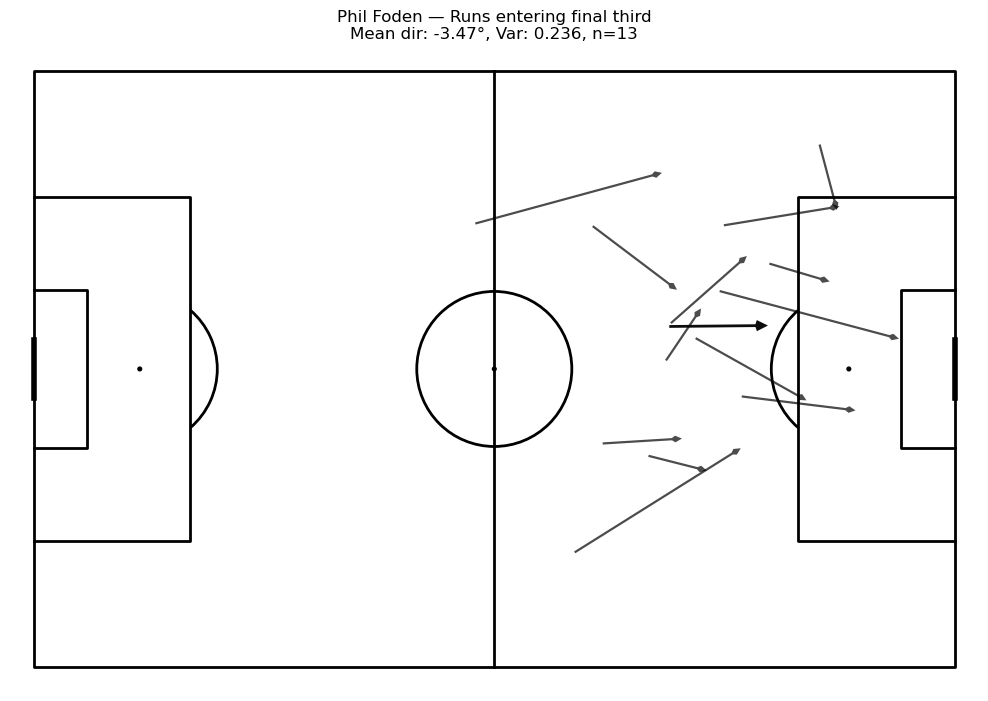

In [23]:
# [C08] Plot all runs + average arrow
# Description: Draw a pitch and overlay arrows for each run; add a single average arrow (mean start/end).

figsize = (10, 7)
avg_start_x = float(player_runs["start_x"].mean())
avg_start_y = float(player_runs["start_y"].mean())
avg_end_x   = float(player_runs["end_x"].mean())
avg_end_y   = float(player_runs["end_y"].mean())

if HAS_MPLSOCCER:
    pitch = Pitch(pitch_type="opta", pitch_color="white", line_color="black")
    fig, ax = pitch.draw(figsize=figsize)
    pitch.arrows(player_runs["start_x"], player_runs["start_y"],
                 player_runs["end_x"],   player_runs["end_y"],
                 width=1.6, headwidth=3, headlength=3, ax=ax, alpha=0.7)
    pitch.arrows(avg_start_x, avg_start_y, avg_end_x, avg_end_y,
                 width=2.0, headwidth=4, headlength=4, ax=ax, alpha=0.95)
else:
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect("equal"); ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.axvline(66.7, ls="--", lw=1, alpha=0.4, color="k")
    for sx, sy, ex, ey in zip(player_runs["start_x"], player_runs["start_y"],
                              player_runs["end_x"],   player_runs["end_y"]):
        ax.arrow(sx, sy, ex - sx, ey - sy, length_includes_head=True,
                 head_width=1.6, head_length=2.6, alpha=0.7)
    ax.arrow(avg_start_x, avg_start_y, avg_end_x - avg_start_x, avg_end_y - avg_start_y,
             length_includes_head=True, head_width=2.2, head_length=3.2, alpha=0.95)

title = (f"{PLAYER} — Runs entering final third\n"
         f"Mean dir: {summary['mean_direction_deg']}°, "
         f"Var: {summary['circular_variance']}, "
         f"n={summary['n_runs']}")
plt.title(title)
plt.tight_layout()
# --- [C08] save the figure from the same cell that draws it ---
# (works for both branches; put this just before plt.show())
fig.savefig("foden_runs_final_third.png", dpi=200, bbox_inches="tight")
plt.show()

In [24]:
# [C09] One-line values for the report
# Description: Print the two required metrics in a copy-paste friendly format.

print(f"Player: {PLAYER}")
print(f"Mean run direction (deg): {summary['mean_direction_deg']}")
print(f"Directional variation (circular variance): {summary['circular_variance']}")
print(f"Number of runs (final third): {summary['n_runs']}")


Player: Phil Foden
Mean run direction (deg): -3.47
Directional variation (circular variance): 0.236
Number of runs (final third): 13


In [25]:
# [C10] (Optional) Quick report template
# Description: A minimal paragraph you can paste into your one-page report.

report_text = f"""
Off-Ball Runs — {PLAYER}

Method. We filtered the match dataset to the player's in-possession, forward runs and
kept only those ending in the final third (end_x ≥ 66.7 on a 0–100 pitch).
For each run we computed the start→end vector and its angle; the single “average direction”
metric is the circular mean angle (degrees), and the single “variation” metric is the circular
variance (0–1, lower = more consistent).

Results. Mean direction = {summary['mean_direction_deg']}°. Directional variation (circular variance) = {summary['circular_variance']}.
n = {summary['n_runs']} runs entering the final third.

Interpretation. The run map shows the dominant channels and typical penetration angles.
Lower variance indicates a more consistent pattern (role clarity), while higher variance
suggests more diverse movements (e.g., inside cuts vs. wide overlaps).
""".strip()

print(report_text)


Off-Ball Runs — Phil Foden

Method. We filtered the match dataset to the player's in-possession, forward runs and
kept only those ending in the final third (end_x ≥ 66.7 on a 0–100 pitch).
For each run we computed the start→end vector and its angle; the single “average direction”
metric is the circular mean angle (degrees), and the single “variation” metric is the circular
variance (0–1, lower = more consistent).

Results. Mean direction = -3.47°. Directional variation (circular variance) = 0.236.
n = 13 runs entering the final third.

Interpretation. The run map shows the dominant channels and typical penetration angles.
Lower variance indicates a more consistent pattern (role clarity), while higher variance
suggests more diverse movements (e.g., inside cuts vs. wide overlaps).


In [26]:
plt.savefig("foden_runs_final_third.png", dpi=200, bbox_inches="tight")


<Figure size 640x480 with 0 Axes>